In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gd

In [85]:
water_data = pd.read_csv("washdash-download.csv")

water_data.head()

,ISO3,Country,Residence Type,Service Type,Year,Coverage,Population,Service level
0,BWA,Botswana,rural,Drinking water,2000,53.99472,423694.4540,At least basic
1,BWA,Botswana,rural,Drinking water,2001,54.01961,424904.8684,At least basic
2,BWA,Botswana,rural,Drinking water,2002,54.04450,428381.4883,At least basic
3,BWA,Botswana,rural,Drinking water,2003,54.06939,431779.9288,At least basic
4,BWA,Botswana,rural,Drinking water,2004,54.09428,435132.6966,At least basic


In [86]:
water_data.columns

Index(['ISO3', 'Country', 'Residence Type', 'Service Type', 'Year', 'Coverage',
       'Population', 'Service level'],
      dtype='str')

In [87]:
water_clean = water_data[(water_data["Service Type"] == "Drinking water") & (water_data["Service level"].isin(["At least basic", "Basic service", "Safely managed service", "Limited service", "Unimproved", "Surface water"])) & (water_data["Year"] >= 2000)]
water_clean.head()

,ISO3,Country,Residence Type,Service Type,Year,Coverage,Population,Service level
0,BWA,Botswana,rural,Drinking water,2000,53.99472,423694.4540,At least basic
1,BWA,Botswana,rural,Drinking water,2001,54.01961,424904.8684,At least basic
2,BWA,Botswana,rural,Drinking water,2002,54.04450,428381.4883,At least basic
3,BWA,Botswana,rural,Drinking water,2003,54.06939,431779.9288,At least basic
4,BWA,Botswana,rural,Drinking water,2004,54.09428,435132.6966,At least basic


In [88]:
water_pivot = water_clean.pivot_table(index = ["ISO3", "Country", "Residence Type", "Year"], columns = "Service level", values = "Coverage").reset_index()

water_pivot["Basic_Access"] = water_pivot["At least basic"]

water_pivot["Basic_Access"] = water_pivot["Basic_Access"].fillna(water_pivot["Basic service"].fillna(0) + water_pivot["Safely managed service"].fillna(0))

water_pivot = water_pivot.rename(columns = {"Surface water": "Surface_water", "Limited service": "Limited_service", "Unimproved": "Unimproved", "Residence Type": "Setting"})

water_pivot["Country"] = water_pivot["Country"].replace({"Democratic Republic of the Congo": "DR Congo"})

water_pivot.head()

Service level,ISO3,Country,Setting,Year,At least basic,Basic service,Limited_service,Safely managed service,Surface_water,Unimproved,Basic_Access
0,BWA,Botswana,rural,2000,53.99472,NaN,37.81006,NaN,6.34986,1.84536,53.99472
1,BWA,Botswana,rural,2001,54.01961,NaN,37.82749,NaN,6.13634,2.01655,54.01961
2,BWA,Botswana,rural,2002,54.04450,NaN,37.84492,NaN,5.92283,2.18774,54.04450
3,BWA,Botswana,rural,2003,54.06939,NaN,37.86235,NaN,5.70932,2.35893,54.06939
4,BWA,Botswana,rural,2004,54.09428,NaN,37.87978,NaN,5.49581,2.53013,54.09428


In [89]:
water_pivot["Setting"].unique()

total_df = water_pivot[water_pivot["Setting"] == "total"]
total_df.head()

Service level,ISO3,Country,Setting,Year,At least basic,Basic service,Limited_service,Safely managed service,Surface_water,Unimproved,Basic_Access
24,BWA,Botswana,total,2000,NaN,16.26257,20.62517,59.19699,3.04667,0.86860,75.45956
25,BWA,Botswana,total,2001,NaN,16.15209,20.35768,59.60286,2.89570,0.99167,75.75495
26,BWA,Botswana,total,2002,NaN,16.08483,20.19814,59.82907,2.76768,1.12028,75.91390
27,BWA,Botswana,total,2003,NaN,16.02374,20.05421,60.02824,2.64455,1.24926,76.05198
28,BWA,Botswana,total,2004,NaN,15.96245,19.91006,60.22644,2.52337,1.37769,76.18889


In [90]:
total_df["Country"].nunique()

10

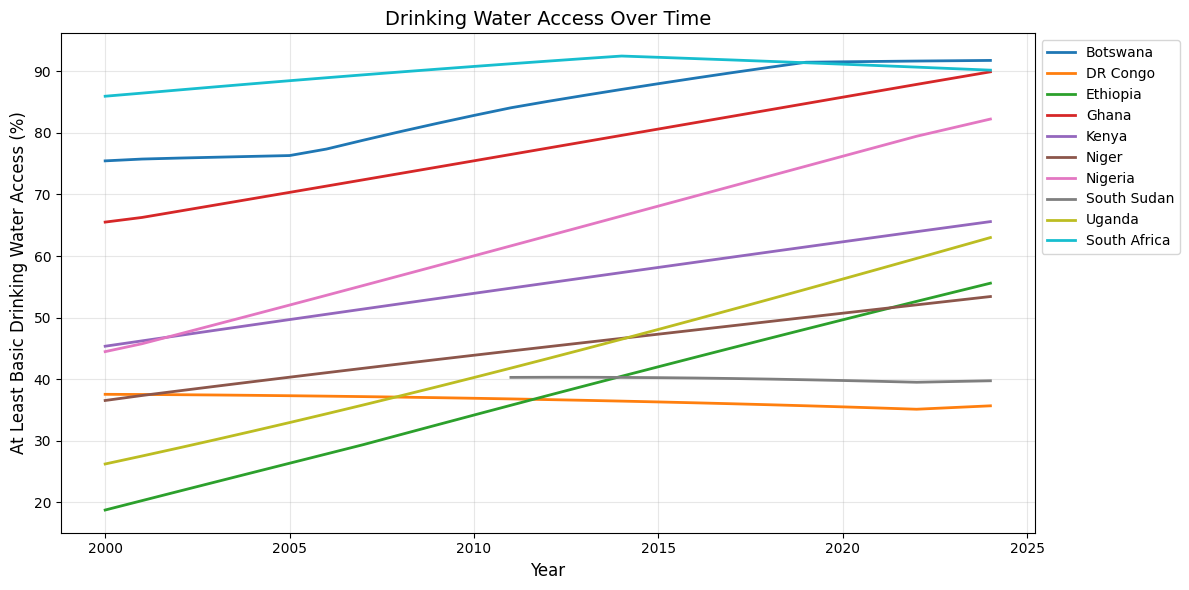

In [91]:
plt.figure(figsize = (12,6))

for country in total_df["Country"].unique():
    country_data = total_df[total_df["Country"] == country]
    plt.plot(country_data["Year"], country_data["Basic_Access"], linewidth = 2, label = country)

plt.xlabel("Year", fontsize = 12)
plt.ylabel("At Least Basic Drinking Water Access (%)", fontsize = 12)
plt.title("Drinking Water Access Over Time", fontsize = 14)
plt.legend(bbox_to_anchor = (1,1), loc = "upper left")
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

In [92]:
# Latest available year for each country
latest_data = total_df.sort_values(["Country", "Year"]).groupby("Country").tail(1)

summary_table = latest_data[["Country", "Year", "Basic_Access", "Surface_water", "Limited_service", "Unimproved"]].sort_values(by = "Basic_Access", ascending = False)

summary_table

Service level,Country,Year,Basic_Access,Surface_water,Limited_service,Unimproved
47,Botswana,2024,91.77136,0.41168,4.27689,3.54006
662,South Africa,2024,90.19168,1.22498,7.45672,1.12662
263,Ghana,2024,89.92201,4.21884,4.47777,1.38138
479,Nigeria,2024,82.24890,3.77914,3.94088,10.03109
335,Kenya,2024,65.59660,18.94249,8.77220,6.68871
590,Uganda,2024,63.00580,3.88939,23.10620,9.99861
191,Ethiopia,2024,55.59607,3.84054,27.70240,12.86099
407,Niger,2024,53.42747,1.80616,16.74793,28.01844
529,South Sudan,2024,39.74944,11.75657,37.89556,10.59843
119,DR Congo,2024,35.68136,7.74371,24.12077,32.45416


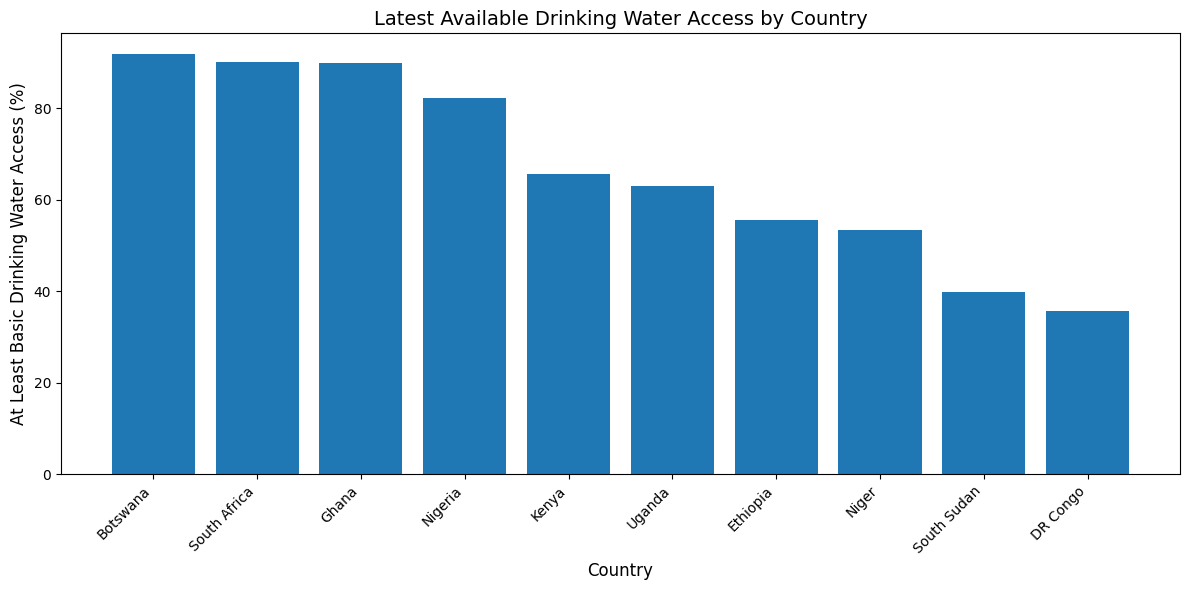

In [93]:
# Bar chart
plt.figure(figsize = (12,6))

plt.bar(summary_table["Country"], summary_table["Basic_Access"])

plt.xlabel("Country", fontsize = 12)
plt.ylabel("At Least Basic Drinking Water Access (%)", fontsize = 12)
plt.title("Latest Available Drinking Water Access by Country", fontsize = 14)
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

In [94]:
urban_rural = water_pivot[water_pivot["Setting"].isin(["urban", "rural"])]

urban_rural.head()

Service level,ISO3,Country,Setting,Year,At least basic,Basic service,Limited_service,Safely managed service,Surface_water,Unimproved,Basic_Access
0,BWA,Botswana,rural,2000,53.99472,NaN,37.81006,NaN,6.34986,1.84536,53.99472
1,BWA,Botswana,rural,2001,54.01961,NaN,37.82749,NaN,6.13634,2.01655,54.01961
2,BWA,Botswana,rural,2002,54.04450,NaN,37.84492,NaN,5.92283,2.18774,54.04450
3,BWA,Botswana,rural,2003,54.06939,NaN,37.86235,NaN,5.70932,2.35893,54.06939
4,BWA,Botswana,rural,2004,54.09428,NaN,37.87978,NaN,5.49581,2.53013,54.09428


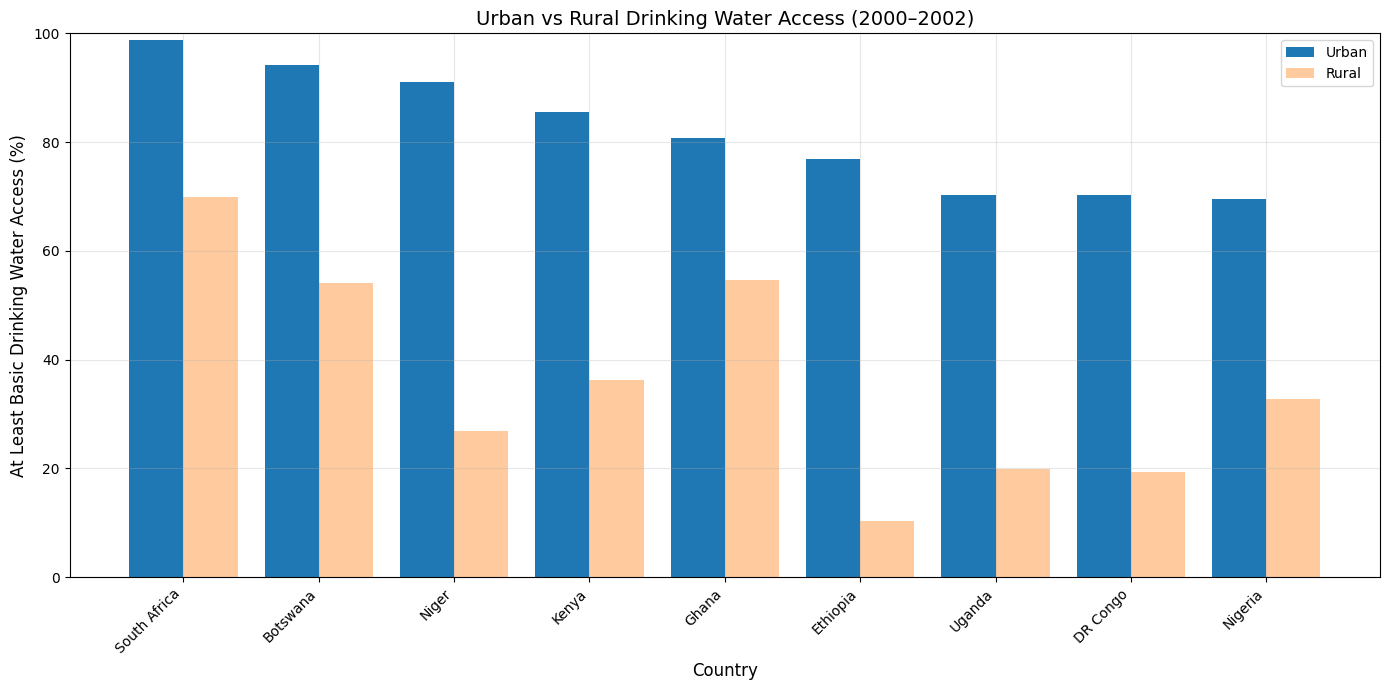

In [95]:
# Urban vs Rural Drinking Water Access (2000–2002)

urban_rural = water_pivot[water_pivot["Setting"].isin(["urban", "rural"])]

# 2000–2002 period
early_period = urban_rural[urban_rural["Year"].between(2000, 2002)]

# Average values
early_avg = early_period.groupby(["Country", "Setting"])["Basic_Access"].mean().reset_index()

# Pivot table
early_pivot = early_avg.pivot(index = "Country", columns = "Setting", values = "Basic_Access")

# Sort by urban access
early_pivot = early_pivot.sort_values(by = "urban",ascending = False)

# Plot
fig, ax = plt.subplots(figsize = (14,7))
x = np.arange(len(early_pivot.index))
width = 0.4

# Urban bars
ax.bar(x - width/2, early_pivot["urban"], width, label = "Urban", alpha = 1.0)

# Rural bars
ax.bar(x + width/2, early_pivot["rural"], width, label = "Rural", alpha = 0.4)
ax.set_xticks(x)
ax.set_xticklabels(early_pivot.index, rotation = 45, ha = "right")
ax.set_ylim(0,100)
ax.set_xlabel("Country", fontsize = 12)
ax.set_ylabel("At Least Basic Drinking Water Access (%)", fontsize = 12)
ax.set_title("Urban vs Rural Drinking Water Access (2000–2002)", fontsize = 14)
ax.legend()
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

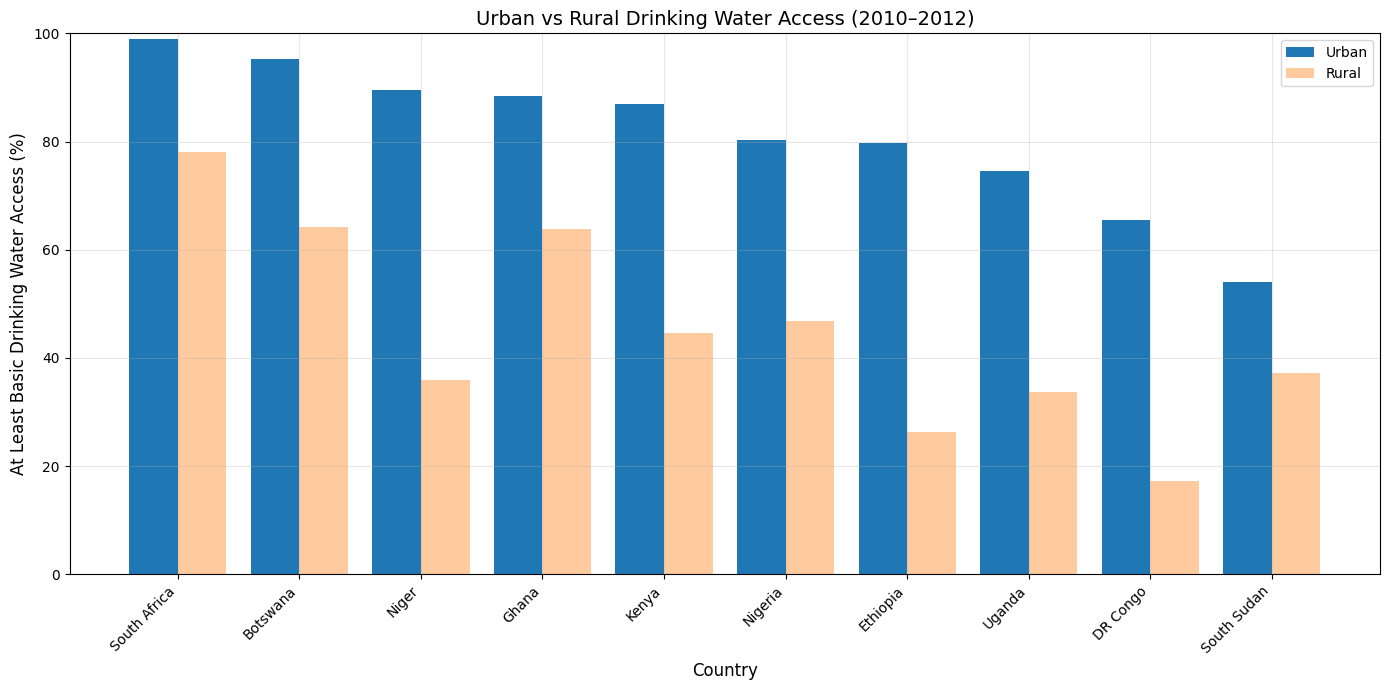

In [96]:
# Urban vs Rural Drinking Water Access (2010–2012)

# 2010–2012 period
middle_period = urban_rural[urban_rural["Year"].between(2010, 2012)]

# Average values
middle_avg = middle_period.groupby(["Country", "Setting"])["Basic_Access"].mean().reset_index()

# Pivot table
middle_pivot = middle_avg.pivot(index = "Country", columns = "Setting", values = "Basic_Access")

# Sort by urban access
middle_pivot = middle_pivot.sort_values(by = "urban", ascending = False)

# Plot
fig, ax = plt.subplots(figsize = (14,7))
x = np.arange(len(middle_pivot.index))
width = 0.4

# Urban bars
ax.bar(x - width/2, middle_pivot["urban"], width, label = "Urban", alpha = 1.0)

# Rural bars
ax.bar(x + width/2, middle_pivot["rural"], width, label = "Rural", alpha = 0.4)
ax.set_xticks(x)
ax.set_xticklabels(middle_pivot.index, rotation = 45, ha = "right")
ax.set_ylim(0,100)
ax.set_xlabel("Country", fontsize = 12)
ax.set_ylabel("At Least Basic Drinking Water Access (%)", fontsize = 12)
ax.set_title("Urban vs Rural Drinking Water Access (2010–2012)", fontsize = 14)
ax.legend()
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

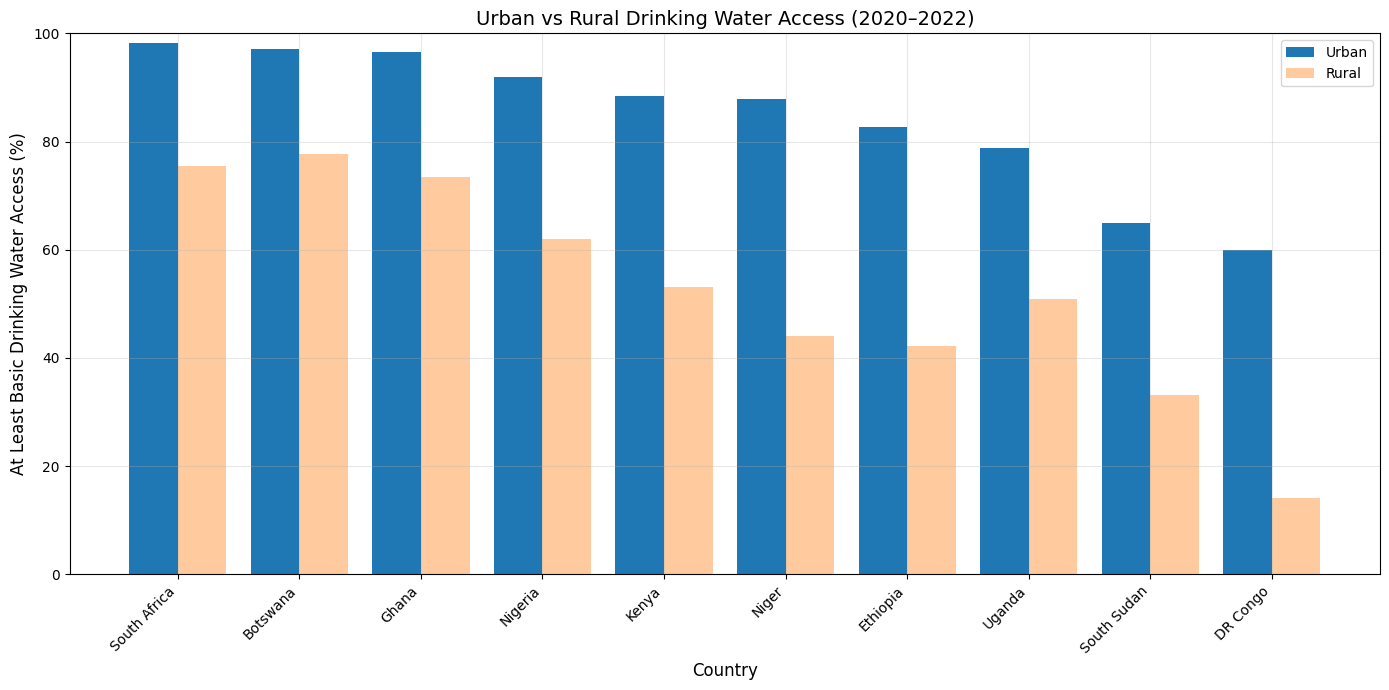

In [97]:
# Urban vs Rural Drinking Water Access (2020–2022)

# 2020–2022 period
recent_period = urban_rural[urban_rural["Year"].between(2020, 2022)]

# Average values
recent_avg = recent_period.groupby(["Country", "Setting"]) ["Basic_Access"].mean().reset_index()

# Pivot table
recent_pivot = recent_avg.pivot(index = "Country", columns = "Setting", values = "Basic_Access")

# Sort by urban access
recent_pivot = recent_pivot.sort_values(by = "urban", ascending = False)

# Plot
fig, ax = plt.subplots(figsize = (14,7))

x = np.arange(len(recent_pivot.index))
width = 0.4

# Urban bars
ax.bar(x - width/2, recent_pivot["urban"], width, label = "Urban", alpha = 1.0)

# Rural bars
ax.bar(x + width/2, recent_pivot["rural"], width, label = "Rural", alpha = 0.4)
ax.set_xticks(x)
ax.set_xticklabels(recent_pivot.index, rotation = 45, ha = "right")
ax.set_ylim(0,100)
ax.set_xlabel("Country", fontsize = 12)
ax.set_ylabel("At Least Basic Drinking Water Access (%)", fontsize = 12)
ax.set_title( "Urban vs Rural Drinking Water Access (2020–2022)", fontsize = 14)
ax.legend()
ax.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

In [98]:
map_data = water_pivot[water_pivot["Setting"] == "total"]
map_latest = map_data.sort_values(["Country", "Year"]).groupby("Country").tail(1)
map_latest.head()

Service level,ISO3,Country,Setting,Year,At least basic,Basic service,Limited_service,Safely managed service,Surface_water,Unimproved,Basic_Access
47,BWA,Botswana,total,2024,NaN,28.48032,4.27689,63.29104,0.41168,3.54006,91.77136
119,COD,DR Congo,total,2024,NaN,23.80871,24.12077,11.87265,7.74371,32.45416,35.68136
191,ETH,Ethiopia,total,2024,NaN,42.04887,27.70240,13.54720,3.84054,12.86099,55.59607
263,GHA,Ghana,total,2024,NaN,46.98062,4.47777,42.94139,4.21884,1.38138,89.92201
335,KEN,Kenya,total,2024,65.5966,NaN,8.77220,NaN,18.94249,6.68871,65.59660


In [99]:
world = gd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
africa = world[world["CONTINENT"] == "Africa"]
africa.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
11,Admin-0 country,1,2,Democratic Republic of the Congo,COD,0,2,Sovereign country,1,Democratic Republic of the Congo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((29.34 -4.49998, 29.51999 -5.41998, 2..."
12,Admin-0 country,1,6,Somalia,SOM,0,2,Sovereign country,1,Somalia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((41.58513 -1.68325, 40.993 -0.85829, ..."
13,Admin-0 country,1,2,Kenya,KEN,0,2,Sovereign country,1,Kenya,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((39.20222 -4.67677, 37.7669 -3.67712,..."


In [100]:
map_latest["Country"] = map_latest["Country"].replace({"DR Congo": "Dem. Rep. Congo"})

In [101]:
merged = africa.merge(map_latest, left_on = "NAME", right_on = "Country", how = "left")
merged.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,Country,Setting,Year,At least basic,Basic service,Limited_service,Safely managed service,Surface_water,Unimproved,Basic_Access
0,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Admin-0 country,1,2,Democratic Republic of the Congo,COD,0,2,Sovereign country,1,Democratic Republic of the Congo,...,Dem. Rep. Congo,total,2024.0,NaN,23.80871,24.12077,11.87265,7.74371,32.45416,35.68136
3,Admin-0 country,1,6,Somalia,SOM,0,2,Sovereign country,1,Somalia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Admin-0 country,1,2,Kenya,KEN,0,2,Sovereign country,1,Kenya,...,Kenya,total,2024.0,65.5966,NaN,8.77220,NaN,18.94249,6.68871,65.59660


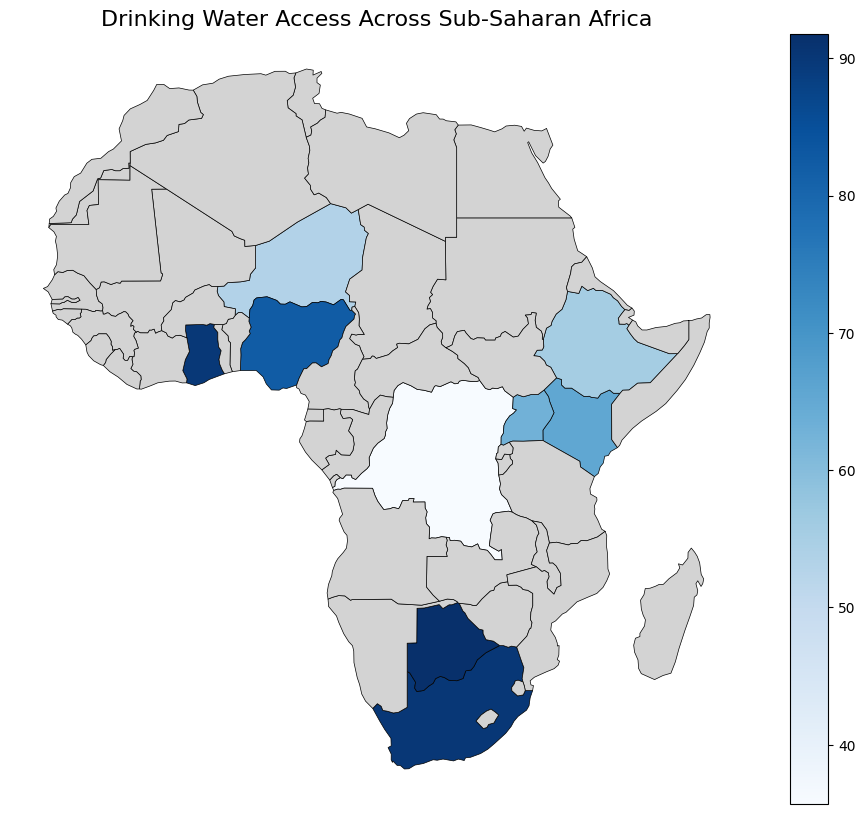

In [102]:
fig, ax = plt.subplots(figsize = (12,10))

merged.plot(column = "Basic_Access", cmap = "Blues", linewidth = 0.5, edgecolor = "black", legend = True, missing_kwds = {"color": "lightgrey", "label": "No Data"}, ax = ax)

ax.set_title("Drinking Water Access Across Sub-Saharan Africa", fontsize = 16)
ax.axis("off")
plt.show()

In [103]:
#ALL COUNTRIES MAP
all_water_data = pd.read_csv("washdash-download-AllCountries.csv")
all_water_data.head()

,ISO3,Country,Residence Type,Service Type,Year,Coverage,Population,Service level
0,AGO,Angola,total,Drinking water,2000,37.84224,6.128501e+06,At least basic
1,AGO,Angola,rural,Drinking water,2000,16.88850,1.365156e+06,At least basic
2,AGO,Angola,urban,Drinking water,2000,58.72318,4.763345e+06,At least basic
3,AGO,Angola,total,Drinking water,2001,38.33882,6.420681e+06,At least basic
4,AGO,Angola,rural,Drinking water,2001,16.88850,1.378143e+06,At least basic


In [104]:
all_water_clean = all_water_data[(all_water_data["Service Type"] == "Drinking water") & (all_water_data["Service level"].isin(["At least basic", "Basic service", "Safely managed service", "Limited service", "Unimproved", "Surface water"])) & (all_water_data["Residence Type"] == "total") & (all_water_data["Year"] >= 2000)]
all_water_clean.head()

,ISO3,Country,Residence Type,Service Type,Year,Coverage,Population,Service level
0,AGO,Angola,total,Drinking water,2000,37.84224,6.128501e+06,At least basic
3,AGO,Angola,total,Drinking water,2001,38.33882,6.420681e+06,At least basic
6,AGO,Angola,total,Drinking water,2002,38.83539,6.729280e+06,At least basic
9,AGO,Angola,total,Drinking water,2003,40.39652,7.248634e+06,At least basic
12,AGO,Angola,total,Drinking water,2004,41.97724,7.807944e+06,At least basic


In [105]:
all_water_pivot = all_water_clean.pivot_table(index = ["ISO3", "Country", "Year"], columns = "Service level",values = "Coverage").reset_index()

# Create consistent Basic_Access metric
all_water_pivot["Basic_Access"] = (all_water_pivot["Basic service"].fillna(0) + all_water_pivot["Safely managed service"].fillna(0))

# Rename columns
all_water_pivot = all_water_pivot.rename(columns = {"Surface water": "Surface_water", "Limited service": "Limited_service"})
all_water_pivot.head()

Service level,ISO3,Country,Year,At least basic,Basic service,Limited_service,Safely managed service,Surface_water,Unimproved,Basic_Access
0,AGO,Angola,2000,37.84224,NaN,17.50666,NaN,31.04646,13.60465,0.0
1,AGO,Angola,2001,38.33882,NaN,17.68751,NaN,30.51142,13.46225,0.0
2,AGO,Angola,2002,38.83539,NaN,17.86837,NaN,29.97639,13.31985,0.0
3,AGO,Angola,2003,40.39652,NaN,17.67374,NaN,28.63965,13.29009,0.0
4,AGO,Angola,2004,41.97724,NaN,17.44198,NaN,27.32646,13.25432,0.0


In [106]:
all_latest = all_water_pivot.sort_values(["Country", "Year"]).groupby("Country").tail(1)
all_latest.head()

Service level,ISO3,Country,Year,At least basic,Basic service,Limited_service,Safely managed service,Surface_water,Unimproved,Basic_Access
22,AGO,Angola,2022,66.47633,NaN,10.95744,NaN,9.63980,12.92644,0.00000
68,BEN,Benin,2022,NaN,51.57156,7.44897,17.38743,3.21432,20.37773,68.95899
114,BWA,Botswana,2022,NaN,27.13479,4.45739,64.53551,0.54582,3.32649,91.67030
91,BFA,Burkina Faso,2022,49.76626,NaN,30.81880,NaN,0.17938,19.23556,0.00000
45,BDI,Burundi,2022,65.69756,NaN,20.52363,NaN,3.56539,10.21342,0.00000


In [107]:
all_latest["Country"] = all_latest["Country"].replace({"Democratic Republic of the Congo": "Dem. Rep. Congo","South Sudan": "S. Sudan"})

In [108]:
world = gd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

africa = world[(world["CONTINENT"] == "Africa")]
africa.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,NaN,NaN,Unrecognized,NaN,NaN,NaN,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
11,Admin-0 country,1,2,Democratic Republic of the Congo,COD,0,2,Sovereign country,1,Democratic Republic of the Congo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((29.34 -4.49998, 29.51999 -5.41998, 2..."
12,Admin-0 country,1,6,Somalia,SOM,0,2,Sovereign country,1,Somalia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((41.58513 -1.68325, 40.993 -0.85829, ..."
13,Admin-0 country,1,2,Kenya,KEN,0,2,Sovereign country,1,Kenya,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((39.20222 -4.67677, 37.7669 -3.67712,..."


In [109]:
merged_all = africa.merge(all_latest, left_on = "NAME", right_on = "Country", how = "left")
merged_all.head()

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,ISO3,Country,Year,At least basic,Basic service,Limited_service,Safely managed service,Surface_water,Unimproved,Basic_Access
0,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Admin-0 country,1,2,Democratic Republic of the Congo,COD,0,2,Sovereign country,1,Democratic Republic of the Congo,...,COD,Dem. Rep. Congo,2022.0,NaN,23.54261,23.97405,11.58474,7.90528,32.99332,35.12735
3,Admin-0 country,1,6,Somalia,SOM,0,2,Sovereign country,1,Somalia,...,SOM,Somalia,2022.0,70.37633,NaN,9.24007,NaN,4.59947,15.78413,0.00000
4,Admin-0 country,1,2,Kenya,KEN,0,2,Sovereign country,1,Kenya,...,KEN,Kenya,2022.0,63.96426,NaN,8.66109,NaN,19.84200,7.53264,0.00000


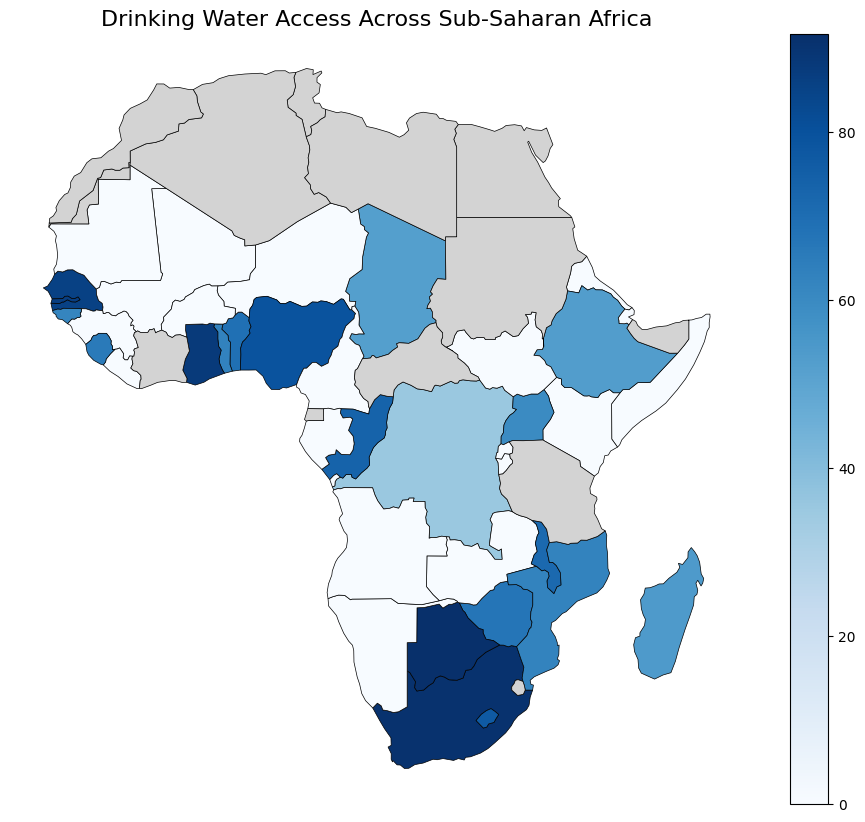

In [110]:
fig, ax = plt.subplots(figsize = (12,10))

merged_all.plot(column = "Basic_Access", cmap = "Blues", linewidth = 0.5, edgecolor = "black",legend = True, missing_kwds = {"color": "lightgrey", "label": "No Data"}, ax = ax)
ax.set_title("Drinking Water Access Across Sub-Saharan Africa", fontsize = 16)
ax.axis("off")
plt.show()